# 05 — Inference, Debugging, and Business Decisions (TensorFlow / Keras)

A useful model must be evaluated on unseen data, inspected for systematic errors, and embedded in a decision policy.


train (5000, 784) test (1000, 784)


2026-09-07 07:30:27.816310: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


              precision    recall  f1-score   support

           0      0.851     0.860     0.856       100
           1      0.739     0.880     0.804       100
           2      0.768     0.530     0.627       100
           3      0.677     0.860     0.758       100
           4      0.664     0.730     0.695       100
           5      0.776     0.450     0.570       100
           6      0.776     0.760     0.768       100
           7      0.826     0.710     0.763       100
           8      0.596     0.650     0.622       100
           9      0.561     0.690     0.619       100

    accuracy                          0.712      1000
   macro avg      0.723     0.712     0.708      1000
weighted avg      0.723     0.712     0.708      1000



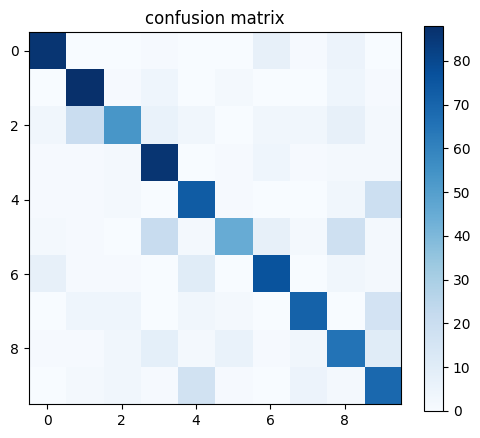

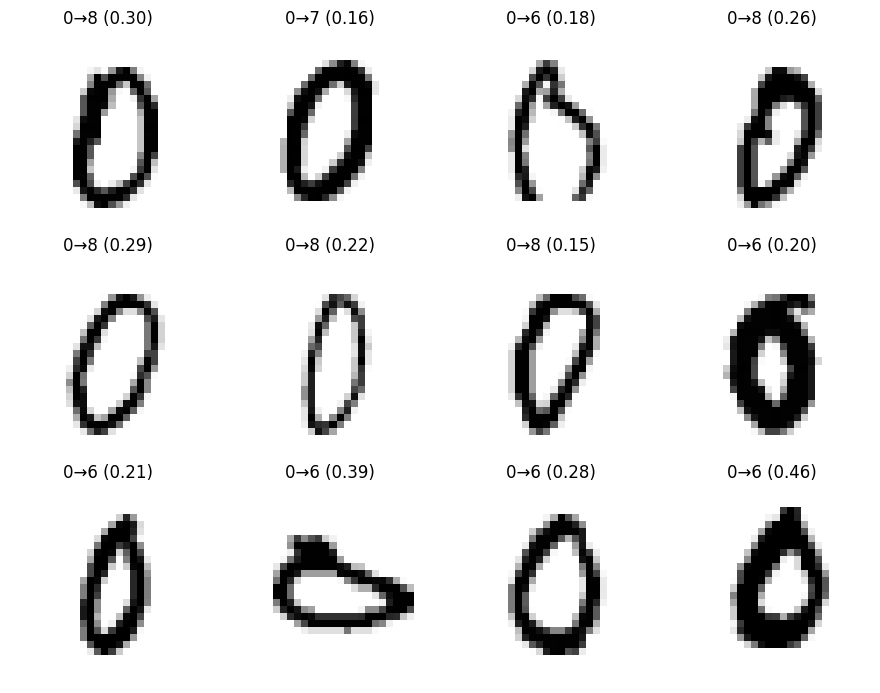

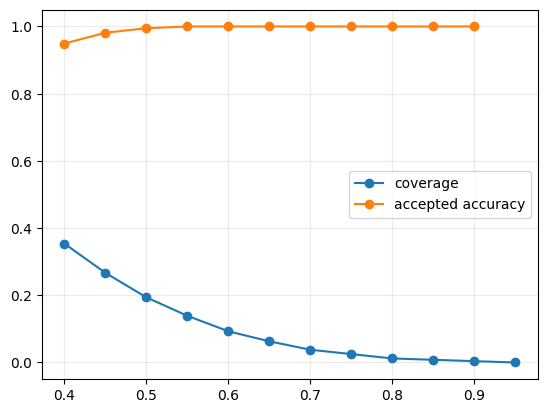

In [1]:
from pathlib import Path
import urllib.request, numpy as np
MNIST_URL='https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz'
CACHE=Path('data/cache/mnist.npz'); CACHE.parent.mkdir(parents=True,exist_ok=True)
if not CACHE.exists():
    print('Downloading official MNIST archive...')
    urllib.request.urlretrieve(MNIST_URL,CACHE)
with np.load(CACHE) as d:
    x_train_full,y_train_full=d['x_train'],d['y_train']
    x_test_full,y_test_full=d['x_test'],d['y_test']
def balanced(x,y,n):
    ids=np.concatenate([np.flatnonzero(y==c)[:n] for c in range(10)])
    return x[ids],y[ids]
x_train_img,y_train=balanced(x_train_full,y_train_full,500)
x_test_img,y_test=balanced(x_test_full,y_test_full,100)
x_train=x_train_img.reshape(len(x_train_img),-1).astype('float32')/255.0
x_test=x_test_img.reshape(len(x_test_img),-1).astype('float32')/255.0
print('train',x_train.shape,'test',x_test.shape)

import tensorflow as tf,matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,classification_report
tf.random.set_seed(42);X=tf.constant(x_train);Y=tf.constant(y_train,dtype=tf.int32);Xt=tf.constant(x_test);model=tf.keras.Sequential([tf.keras.layers.Input((784,)),tf.keras.layers.Dense(64,activation='relu'),tf.keras.layers.Dense(10)]);opt=tf.keras.optimizers.SGD(.25)
for _ in range(10):
 with tf.GradientTape() as tape:q=model(X,training=True);loss=tf.reduce_mean(tf.keras.losses.sparse_categorical_crossentropy(Y,q,from_logits=True))
 g=tape.gradient(loss,model.trainable_variables);opt.apply_gradients(zip(g,model.trainable_variables))
p=tf.nn.softmax(model(Xt,training=False),1).numpy();pred=p.argmax(1);conf=p.max(1);print(classification_report(y_test,pred,digits=3));cm=confusion_matrix(y_test,pred);plt.figure(figsize=(6,5));plt.imshow(cm,cmap='Blues');plt.colorbar();plt.title('confusion matrix');plt.show();wrong=np.flatnonzero(pred!=y_test)[:12];fig,axes=plt.subplots(3,4,figsize=(9,7))
for ax,i in zip(axes.ravel(),wrong):ax.imshow(x_test_img[i],cmap='gray_r');ax.set_title(f'{y_test[i]}→{pred[i]} ({conf[i]:.2f})');ax.axis('off')
plt.tight_layout();plt.show();ths=np.linspace(.4,.95,12);cov=[];acc=[]
for t in ths:m=conf>=t;cov.append(m.mean());acc.append((pred[m]==y_test[m]).mean() if m.any() else np.nan)
plt.plot(ths,cov,marker='o',label='coverage');plt.plot(ths,acc,marker='o',label='accepted accuracy');plt.legend();plt.grid(alpha=.25);plt.show()


## Confidence is not correctness
A normalized softmax score is not a guarantee. Wrong predictions can still be confident. In production, low-confidence cases may be routed to review, while high-risk systems may require calibration and explicit abstention.


## Business interpretation
Imagine MNIST-like digit recognition inside document ingestion. Raising the confidence threshold can improve automated-decision accuracy while reducing automation coverage and increasing manual-review volume.

The operational optimum depends on **error cost + review capacity + latency + risk tolerance**, not accuracy alone.

### Final mental model
- forward pass = current belief
- loss = quantified error
- backprop = responsibility assignment
- update = parameter correction
- representation learning = changing hidden geometry
- inference = applying the learned function to unseen data
- business policy = turning model scores into actions
